In [1]:

# Celula 1: prepara o ambiente de trabalho para toda a analise.
# Mantem a mesma estrutura do notebook XGBoost para permitir comparacao justa.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    r2_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay,
)

# Instala automaticamente o optuna apenas se ele nao estiver disponivel.
try:
    import optuna
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

# Instala automaticamente o optuna-dashboard apenas se ele nao estiver disponivel.
try:
    import optuna_dashboard
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna-dashboard", "-q"])
    import optuna_dashboard

pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Celula 2: leitura da base e preparo das variaveis de entrada.
# MESMO pipeline/features do XGBoost para comparacao direta.
csv_path = Path("../../tabela_final/table_orders_holidays_ecommerce_events.csv") # Path(r"C:\Users\otavi\OneDrive\Desktop\last-mile-tcc\backend\tabela_final\table_orders_holidays_ecommerce_events.csv")
df = pd.read_csv(csv_path)

target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# =====================================================================
# 1. ENGENHARIA DO SLA (Prazo da Transportadora - LAST MILE)
# =====================================================================
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], utc=True)
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], utc=True)
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Quantos dias a transportadora tem para entregar apos pegar o pacote?
df['prazo_transportadora_dias'] = (df['order_estimated_delivery_date'] - df['order_delivered_carrier_date']).dt.days

# Remover os casos onde a transportadora nunca pegou o pacote para evitar NaN no treino
df = df.dropna(subset=['prazo_transportadora_dias']).copy()

# Extraindo o mes da compra (sazonalidade - Black Friday, Natal)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
# df['carrier_month'] = df['order_delivered_carrier_date'].dt.month

# =====================================================================
# 1b. FEATURES DE INTERAÇÃO (Adicionadas para aumentar o sinal)
# =====================================================================
df['prazo_por_km'] = df['prazo_transportadora_dias'] / (df['distance_km'] + 1)
df['frete_por_kg'] = df['freight_value'] / (df['product_weight_g'] / 1000 + 0.1)
df['densidade_produto'] = df['product_weight_g'] / (df['volume_cm3'] + 1)

# =====================================================================
# 2. ORDENAÇÃO CRONOLÓGICA (Baseada no momento da coleta)
# =====================================================================
df = df.sort_values('order_delivered_carrier_date').reset_index(drop=True)

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
date_col = df['order_delivered_carrier_date'].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
# Inverte o alvo: atraso = 1, no prazo = 0.
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier", # variável n ajudou no modelo
    "interval_code_delivered_customer",
    "order_estimated_delivery_date", # Ja usamos
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    # "had_ecommerce_event_14_days_ago",
    
    # --- FEATURES REDUNDANTES / BAIXA INFLUENCIA REMOVIDAS ---
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend"
]

# colunas_remover = [
#     # Vazamento de dados / multicolinearidade
#     "order_purchase_timestamp",
#     "order_approved_at",
#     "order_delivered_carrier_date",
#     "interval_code_delivered_carrier",
#     "order_delivered_customer_date",
#     "interval_code_delivered_customer",
#     "order_estimated_delivery_date",
#     "shipping_limit_date",
#     "is_holiday_in_7_days",
#     "is_holiday_in_14_days",
#     "had_holiday_7_days_ago",
#     "had_holiday_14_days_ago",
#     "delivered_on_time",
#     # "customer_city", # Mantido para Target Encoding
#     # "seller_city", # Mantido para Target Encoding
#     # "category_name", # Mantido para Target Encoding
#     "review_score",
#     "delivery_time_days"
# ]

X = X.drop(columns=colunas_remover, errors='ignore')

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# =====================================================================
# ENGENHARIA DE FEATURES: TARGET ENCODING SUAVIZADO (Cidades)
# =====================================================================
media_global_atraso = y_train.mean()
m = 10 

# Target encoding para customer_city
counts_customer = X_train['customer_city'].value_counts()
means_customer = y_train.groupby(X_train['customer_city']).mean()
smooth_customer = (counts_customer * means_customer + m * media_global_atraso) / (counts_customer + m)

# Target encoding para seller_city
counts_seller = X_train['seller_city'].value_counts()
means_seller = y_train.groupby(X_train['seller_city']).mean()
smooth_seller = (counts_seller * means_seller + m * media_global_atraso) / (counts_seller + m)

# Aplicando as features
X_train['customer_city_encoded'] = X_train['customer_city'].map(smooth_customer)
X_train['seller_city_encoded'] = X_train['seller_city'].map(smooth_seller)

# No teste, o que não existir no treino vai preencher com a média global
X_test['customer_city_encoded'] = X_test['customer_city'].map(smooth_customer).fillna(media_global_atraso)
X_test['seller_city_encoded'] = X_test['seller_city'].map(smooth_seller).fillna(media_global_atraso)

# Target encoding para category_name (preenchendo nulos com 'Unknown')
X_train['category_name'] = X_train['category_name'].fillna('Unknown')
X_test['category_name'] = X_test['category_name'].fillna('Unknown')
counts_cat = X_train['category_name'].value_counts()
means_cat = y_train.groupby(X_train['category_name']).mean()
smooth_cat = (counts_cat * means_cat + m * media_global_atraso) / (counts_cat + m)
X_train['category_name_encoded'] = X_train['category_name'].map(smooth_cat).fillna(media_global_atraso)
X_test['category_name_encoded'] = X_test['category_name'].map(smooth_cat).fillna(media_global_atraso)

# Agora podemos dropar as strings originais
X_train = X_train.drop(columns=['customer_city', 'seller_city', 'category_name'])
X_test = X_test.drop(columns=['customer_city', 'seller_city', 'category_name'])

# =====================================================================
# STANDARDSCALER: normaliza as features numéricas (incluindo as recém criadas)
# =====================================================================
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

pos_count = int((y_train == 1).sum())
total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: Linhas: {X.shape[0]:,} | Colunas: {X.shape[1]}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {pos_count} ({(y_train == 1).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {(y_test == 1).sum()} ({(y_test == 1).mean():.2%} do teste)\n")

X_test.head()


Total de registros: Linhas: 33,820 | Colunas: 26

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



,holiday_at_carrier,days_since_last_holiday,days_until_next_holiday,ecommerce_event_at_carrier,days_since_last_ecommerce_event,days_until_next_ecommerce_event,is_ecommerce_event_in_7_days,is_ecommerce_event_in_14_days,had_ecommerce_event_7_days_ago,had_ecommerce_event_14_days_ago,purchase_hour,purchase_day_of_week,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,prazo_transportadora_dias,purchase_month,prazo_por_km,frete_por_kg,densidade_produto,customer_city_encoded,seller_city_encoded,category_name_encoded
28706,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,0.051970,1.113996,-0.275534,0.247627,-0.528927,-0.532020,-0.599951,-0.399036,0.172915,0.063254,-0.150907,1.802223,-0.228300,-1.027911,-1.149808,1.088629
28707,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,0.992364,1.113996,-0.550846,0.411442,0.251858,-0.149328,1.850664,-0.399036,0.172915,0.063254,-0.448753,-0.893705,0.076460,-0.001782,-1.732835,-2.543861
28708,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-0.888424,1.645101,0.217681,0.349714,-0.434870,-0.571159,0.953099,-0.399036,0.783477,0.063254,-0.402380,0.422915,-0.067894,-0.001782,0.855958,0.042811
28709,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-1.264582,1.645101,-0.356427,0.231008,-0.510769,-0.721992,0.501758,-0.399036,0.325556,0.063254,-0.392665,1.345886,0.379701,-0.846551,0.043177,0.042811
28710,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-0.136109,1.113996,0.105127,1.406198,0.598672,1.249832,-0.266450,-0.399036,-0.742926,0.063254,-0.375918,-0.918190,-0.150108,-1.348589,-0.175591,-0.708816


In [3]:

# Celula 3: define funcoes e configuracoes da busca de hiperparametros.
# A avaliacao trata "atraso" como classe positiva (1), igual ao XGBoost.
def metricas_atraso(y_true, y_pred_atraso, y_proba_atraso):
    return {
        "accuracy_atraso": accuracy_score(y_true, y_pred_atraso),
        "precision_atraso": precision_score(y_true, y_pred_atraso, zero_division=0),
        "recall_atraso": recall_score(y_true, y_pred_atraso, zero_division=0),
        "f1_atraso": f1_score(y_true, y_pred_atraso, zero_division=0),
        "f2_atraso": fbeta_score(y_true, y_pred_atraso, beta=2, zero_division=0),
        "roc_auc_atraso": roc_auc_score(y_true, y_proba_atraso),
        "pr_auc_atraso": average_precision_score(y_true, y_proba_atraso),
        # "r2_atraso": r2_score(y_true, y_proba_atraso),
        "balanced_accuracy_atraso": balanced_accuracy_score(y_true, y_pred_atraso),
        "mcc_atraso": matthews_corrcoef(y_true, y_pred_atraso),
        "brier_score_atraso": brier_score_loss(y_true, y_proba_atraso),
        "log_loss_atraso": log_loss(y_true, y_proba_atraso),
    }


def metricas_gerais(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        # "R2": r2_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
    }

# Mesmas configuracoes gerais do XGBoost.
n_trials = 50
study_seed = 42
cv_tune = TimeSeriesSplit(n_splits=5)
threshold_grid_tune = np.arange(0.05, 0.81, 0.01)

# Vetor binario: 1 = atraso, 0 = nao atraso.
y_train_atraso = y_train.values

print("Preparacao da busca de hiperparametros concluida.")


Preparacao da busca de hiperparametros concluida.


In [4]:

# Celula 4: busca de hiperparametros com Optuna + validacao cruzada temporal.
# Mesmo criterio do XGBoost: maximizar PR-AUC.
# O limiar e escolhido pelo F1, com desempate por Recall e Precision.
#
# Equivalencias usadas:
# XGBoost n_estimators        -> RandomForest n_estimators
# XGBoost max_depth           -> RandomForest max_depth
# XGBoost subsample           -> RandomForest max_samples
# XGBoost colsample_bytree    -> RandomForest max_features
# XGBoost min_child_weight    -> RandomForest min_samples_leaf (aproximacao)
# XGBoost gamma/reg_alpha/... -> sem equivalente exato; usamos min_samples_split
#                                e ccp_alpha para controlar complexidade/poda.

optuna_db_path = Path("optuna_rf_temporal.db").resolve()
study_storage = f"sqlite:///{optuna_db_path.as_posix()}"
study_name = "rf_temporal_mesmo_pipeline_xgb_v1"

def objective(trial):
    params = {
        # Mesma faixa usada no XGBoost.
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 4),

        # Equivalente ao subsample do XGBoost: proporcao das linhas por arvore.
        "max_samples": trial.suggest_float("max_samples", 0.5, 0.8),

        # Equivalente ao colsample_bytree: proporcao das features por divisao.
        "max_features": trial.suggest_float("max_features", 0.5, 0.8),

        # Aproximacao de min_child_weight para restringir folhas pequenas.
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 50),

        # Controles proprios do Random Forest para reduzir overfitting.
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 50),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.01),
    }

    oof_proba_atraso = np.zeros(len(y_train), dtype=float)
    valid_oof_mask = np.zeros(len(y_train), dtype=bool)

    for fold, (tr_idx, va_idx) in enumerate(cv_tune.split(X_train, y_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        mdl = RandomForestClassifier(
            random_state=1000 + trial.number * 10 + fold,
            n_jobs=-1,
            bootstrap=True,
            class_weight="balanced",
            **params,
        )

        mdl.fit(X_tr, y_tr)

        # Probabilidade de atraso = classe positiva (1).
        proba_atraso_va = mdl.predict_proba(X_va)[:, 1]
        oof_proba_atraso[va_idx] = proba_atraso_va
        valid_oof_mask[va_idx] = True

    # TimeSeriesSplit nao usa o bloco inicial como validacao.
    # Avaliamos apenas observacoes que receberam previsao OOF.
    y_oof = y_train_atraso[valid_oof_mask]
    p_oof = oof_proba_atraso[valid_oof_mask]

    pr_auc_i = average_precision_score(y_oof, p_oof)

    best_thr_i = 0.50
    best_f1_i = -1.0
    best_recall_i = -1.0
    best_precision_i = -1.0

    for thr in threshold_grid_tune:
        pred_atraso = (p_oof >= thr).astype(int)
        precision_i = precision_score(y_oof, pred_atraso, zero_division=0)
        recall_i = recall_score(y_oof, pred_atraso, zero_division=0)
        f1_i = f1_score(y_oof, pred_atraso, zero_division=0)

        if (f1_i > best_f1_i) or (
            np.isclose(f1_i, best_f1_i) and recall_i > best_recall_i
        ) or (
            np.isclose(f1_i, best_f1_i)
            and np.isclose(recall_i, best_recall_i)
            and precision_i > best_precision_i
        ):
            best_f1_i = float(f1_i)
            best_recall_i = float(recall_i)
            best_precision_i = float(precision_i)
            best_thr_i = float(thr)

    trial.set_user_attr("best_threshold", best_thr_i)
    trial.set_user_attr("cv_pr_auc_atraso", pr_auc_i)
    trial.set_user_attr("cv_f1_atraso", best_f1_i)
    trial.set_user_attr("cv_recall_atraso", best_recall_i)
    trial.set_user_attr("cv_precision_atraso", best_precision_i)

    return pr_auc_i


sampler = optuna.samplers.TPESampler(seed=study_seed)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name=study_name,
    storage=study_storage,
    load_if_exists=True,
)
study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

best_trial = study.best_trial
best_params_v2 = best_trial.params
best_threshold_v2 = float(best_trial.user_attrs["best_threshold"])

tuning_rows = []
for t in study.trials:
    if t.value is None:
        continue
    tuning_rows.append({
        "candidate": t.number + 1,
        "cv_pr_auc_atraso": t.user_attrs.get("cv_pr_auc_atraso", np.nan),
        "cv_f1_atraso": t.user_attrs.get("cv_f1_atraso", np.nan),
        "cv_recall_atraso": t.user_attrs.get("cv_recall_atraso", np.nan),
        "cv_precision_atraso": t.user_attrs.get("cv_precision_atraso", np.nan),
        "best_threshold": t.user_attrs.get("best_threshold", np.nan),
        "params": t.params,
    })

df_tuning = pd.DataFrame(tuning_rows).sort_values(
    ["cv_pr_auc_atraso", "cv_f1_atraso", "cv_recall_atraso", "cv_precision_atraso"],
    ascending=False,
).reset_index(drop=True)

print(f"Trials avaliados: {len(df_tuning)}")
print("Top 8 configuracoes pela validacao cruzada (PR-AUC -> F1 -> Recall):")
display(df_tuning.head(8))

print("\nMelhores hiperparametros encontrados:")
for key, value in best_params_v2.items():
    print(f" - {key}: {value}")

print(f"Melhor limiar (Optuna): {best_threshold_v2:.2f}")
print(f"Study name: {study_name}")
print(f"Comando dashboard: optuna-dashboard {study_storage} --port 8080")


[I 2026-10-04 11:39:01,308] Using an existing study with `study_name='rf_temporal_mesmo_pipeline_xgb_v1'` instead of creating a new one.
[I 2026-10-04 11:39:09,136] Trial 50 finished with value: 0.3515144193960118 and parameters: {'n_estimators': 250, 'max_depth': 4, 'max_samples': 0.645667023797047, 'max_features': 0.6260066765779276, 'min_samples_leaf': 15, 'min_samples_split': 45, 'ccp_alpha': 0.00058422365338469}. Best is trial 45 with value: 0.35688266132421664.
[I 2026-10-04 11:39:16,292] Trial 51 finished with value: 0.3512725359753529 and parameters: {'n_estimators': 250, 'max_depth': 4, 'max_samples': 0.6675102000670872, 'max_features': 0.5966261033850159, 'min_samples_leaf': 19, 'min_samples_split': 40, 'ccp_alpha': 0.00030966156987974976}. Best is trial 45 with value: 0.35688266132421664.
[I 2026-10-04 11:39:22,928] Trial 52 finished with value: 0.3490944603227707 and parameters: {'n_estimators': 250, 'max_depth': 4, 'max_samples': 0.6648752070812057, 'max_features': 0.62307

Trials avaliados: 100
Top 8 configuracoes pela validacao cruzada (PR-AUC -> F1 -> Recall):


,candidate,cv_pr_auc_atraso,cv_f1_atraso,cv_recall_atraso,cv_precision_atraso,best_threshold,params
0,77,0.357763,0.360119,0.299258,0.452055,0.74,"{'n_estimators': 200, 'max_depth': 4, 'max_sam..."
1,46,0.356883,0.357071,0.293487,0.455826,0.74,"{'n_estimators': 200, 'max_depth': 4, 'max_sam..."
2,58,0.355070,0.363369,0.305853,0.447527,0.74,"{'n_estimators': 200, 'max_depth': 4, 'max_sam..."
3,50,0.354934,0.358974,0.311624,0.423292,0.73,"{'n_estimators': 250, 'max_depth': 4, 'max_sam..."
4,67,0.354900,0.355197,0.290190,0.457737,0.75,"{'n_estimators': 250, 'max_depth': 4, 'max_sam..."
5,60,0.354837,0.362245,0.292663,0.475234,0.75,"{'n_estimators': 150, 'max_depth': 4, 'max_sam..."
6,55,0.354408,0.357041,0.308326,0.424036,0.73,"{'n_estimators': 200, 'max_depth': 4, 'max_sam..."
7,97,0.353980,0.358224,0.302556,0.438995,0.74,"{'n_estimators': 200, 'max_depth': 4, 'max_sam..."



Melhores hiperparametros encontrados:
 - n_estimators: 200
 - max_depth: 4
 - max_samples: 0.6784602913667271
 - max_features: 0.66935193572193
 - min_samples_leaf: 26
 - min_samples_split: 46
 - ccp_alpha: 9.178489532569035e-05
Melhor limiar (Optuna): 0.74
Study name: rf_temporal_mesmo_pipeline_xgb_v1
Comando dashboard: optuna-dashboard sqlite:///C:/FACULDADE/tcc/backend/modelo/split-temporal/optuna_rf_temporal.db --port 8080


Metricas no teste (foco em atraso):


,Teste
accuracy_atraso,0.7955
precision_atraso,0.3526
recall_atraso,0.8450
f1_atraso,0.4976
f2_atraso,0.6605
roc_auc_atraso,0.8979
pr_auc_atraso,0.6997
balanced_accuracy_atraso,0.8169
mcc_atraso,0.4549
brier_score_atraso,0.3074



Como interpretar as metricas:
- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.
- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.
- f1_atraso: media harmonica entre precision e recall.
- f2_atraso: semelhante ao F1, mas dando mais peso ao recall.
- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares.
- pr_auc_atraso: qualidade do trade-off precision x recall para a classe rara.


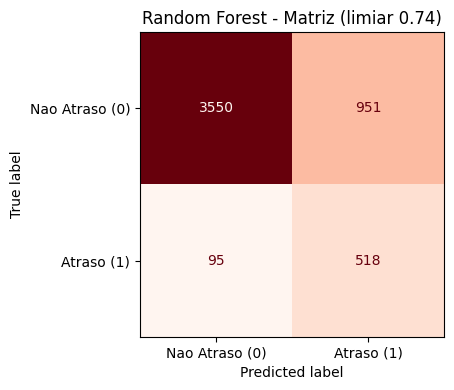

Resumo (teste):
- Limiar adotado: 0.74
- Precision atraso: 0.3526
- Recall atraso: 0.8450
- F2 atraso: 0.6605
- ROC-AUC atraso: 0.8979
- PR-AUC atraso: 0.6997


In [5]:

# Celula 5: treino final do Random Forest com os melhores hiperparametros + avaliacao no teste.
model_v2 = RandomForestClassifier(
    random_state=4242,
    n_jobs=-1,
    bootstrap=True,
    class_weight="balanced",
    **best_params_v2,
)

model_v2.fit(X_train, y_train)

# Probabilidade de atraso (classe 1).
y_proba_v2_train = model_v2.predict_proba(X_train)[:, 1]
y_proba_v2_test = model_v2.predict_proba(X_test)[:, 1]

# Mesmo threshold otimizado na validacao temporal.
y_pred_v2_train = (y_proba_v2_train >= best_threshold_v2).astype(int)
y_pred_v2_test = (y_proba_v2_test >= best_threshold_v2).astype(int)

res_v2_train = metricas_atraso(y_train, y_pred_v2_train, y_proba_v2_train)
res_v2_test = metricas_atraso(y_test, y_pred_v2_test, y_proba_v2_test)
metricas_treino_v2 = metricas_gerais(y_train, y_pred_v2_train, y_proba_v2_train)
metricas_teste_v2 = metricas_gerais(y_test, y_pred_v2_test, y_proba_v2_test)

print("Metricas no teste (foco em atraso):")
display(pd.DataFrame(pd.Series(res_v2_test, name="Teste")).round(4))

print("\nComo interpretar as metricas:")
print("- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.")
print("- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.")
print("- f1_atraso: media harmonica entre precision e recall.")
print("- f2_atraso: semelhante ao F1, mas dando mais peso ao recall.")
print("- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares.")
print("- pr_auc_atraso: qualidade do trade-off precision x recall para a classe rara.")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_v2_test,
    cmap="Reds",
    ax=ax,
    colorbar=False,
    display_labels=["Nao Atraso (0)", "Atraso (1)"],
)
ax.set_title(f"Random Forest - Matriz (limiar {best_threshold_v2:.2f})")
plt.tight_layout()
plt.show()

print("Resumo (teste):")
print(f"- Limiar adotado: {best_threshold_v2:.2f}")
print(f"- Precision atraso: {res_v2_test['precision_atraso']:.4f}")
print(f"- Recall atraso: {res_v2_test['recall_atraso']:.4f}")
print(f"- F2 atraso: {res_v2_test['f2_atraso']:.4f}")
print(f"- ROC-AUC atraso: {res_v2_test['roc_auc_atraso']:.4f}")
print(f"- PR-AUC atraso: {res_v2_test['pr_auc_atraso']:.4f}")
# print(f"- R2 atraso: {res_v2_test['r2_atraso']:.4f}")


In [6]:
# Celula 6: tabelas de metricas de atraso (classe 1).
print("=" * 120)
print("METRICAS DE ATRASO (CLASSE 1)")
print("=" * 120)

print("\n(Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)")

print("\n" + "-" * 120)
print("TREINO (ATRASO)")
print("-" * 120)
df_v2_train_atraso = pd.DataFrame(pd.Series(res_v2_train, name="Treino"))
display(df_v2_train_atraso.round(4))

print("\n" + "-" * 120)
print("TESTE (ATRASO)")
print("-" * 120)
df_v2_test_atraso = pd.DataFrame(pd.Series(res_v2_test, name="Teste"))
display(df_v2_test_atraso.round(4))

# ============================================================================
# RESUMO
# ============================================================================
print("RESUMO\n")
print("─" * 120 + "\n")
print(f"  Limiar utilizado: {best_threshold_v2:.2f}")
print(
    f"  Treino - Accuracy: {metricas_treino_v2['Accuracy']:.4f}, ROC-AUC: {metricas_treino_v2['ROC-AUC']:.4f}, "
    f"Precision (Atraso): {res_v2_train['precision_atraso']:.4f}, Recall (Atraso): {res_v2_train['recall_atraso']:.4f}"
)
print(
    f"  Teste  - Accuracy: {metricas_teste_v2['Accuracy']:.4f}, ROC-AUC: {metricas_teste_v2['ROC-AUC']:.4f},"
    f"Precision (Atraso): {res_v2_test['precision_atraso']:.4f}, Recall (Atraso): {res_v2_test['recall_atraso']:.4f}"
)


METRICAS DE ATRASO (CLASSE 1)

(Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)

------------------------------------------------------------------------------------------------------------------------
TREINO (ATRASO)
------------------------------------------------------------------------------------------------------------------------


,Treino
accuracy_atraso,0.9551
precision_atraso,0.5952
recall_atraso,0.2961
f1_atraso,0.3955
f2_atraso,0.3292
roc_auc_atraso,0.8525
pr_auc_atraso,0.4394
balanced_accuracy_atraso,0.6428
mcc_atraso,0.3997
brier_score_atraso,0.1451



------------------------------------------------------------------------------------------------------------------------
TESTE (ATRASO)
------------------------------------------------------------------------------------------------------------------------


,Teste
accuracy_atraso,0.7955
precision_atraso,0.3526
recall_atraso,0.8450
f1_atraso,0.4976
f2_atraso,0.6605
roc_auc_atraso,0.8979
pr_auc_atraso,0.6997
balanced_accuracy_atraso,0.8169
mcc_atraso,0.4549
brier_score_atraso,0.3074


RESUMO

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

  Limiar utilizado: 0.74
  Treino - Accuracy: 0.9551, ROC-AUC: 0.8525, Precision (Atraso): 0.5952, Recall (Atraso): 0.2961
  Teste  - Accuracy: 0.7955, ROC-AUC: 0.8979,Precision (Atraso): 0.3526, Recall (Atraso): 0.8450


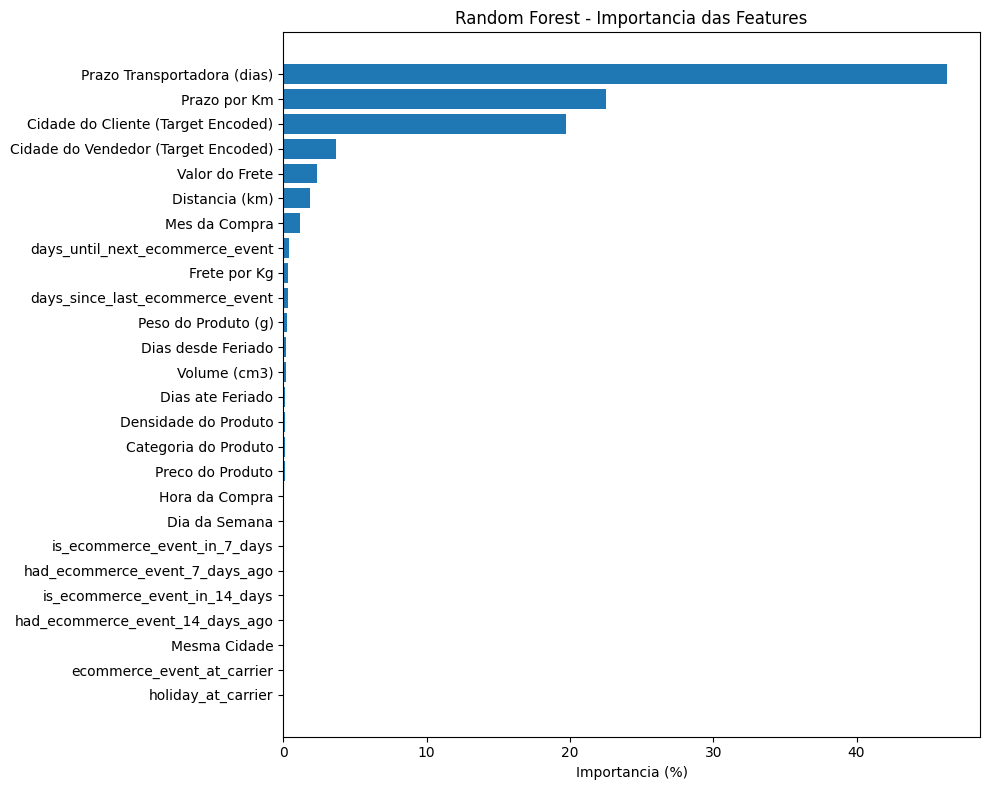


=== Resumo de importancia ===
  Prazo Transportadora (dias)               46.30%
  Prazo por Km                              22.56%
  Cidade do Cliente (Target Encoded)        19.70%
  Cidade do Vendedor (Target Encoded)        3.69%
  Valor do Frete                             2.37%
  Distancia (km)                             1.87%
  Mes da Compra                              1.19%
  days_until_next_ecommerce_event            0.37%
  Frete por Kg                               0.36%
  days_since_last_ecommerce_event            0.32%
  Peso do Produto (g)                        0.24%
  Dias desde Feriado                         0.21%
  Volume (cm3)                               0.18%
  Dias ate Feriado                           0.14%
  Densidade do Produto                       0.13%
  Categoria do Produto                       0.13%
  Preco do Produto                           0.10%
  Hora da Compra                             0.06%
  Dia da Semana                              0.05%


In [7]:

# Celula Extra: Importancia das Features do Random Forest.
import matplotlib.pyplot as plt
import pandas as pd

df_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_v2.feature_importances_,
}).sort_values("importance", ascending=True)

df_imp["importance_pct"] = df_imp["importance"] / df_imp["importance"].sum() * 100

rename_map = {
    "prazo_transportadora_dias": "Prazo Transportadora (dias)",
    "distance_km": "Distancia (km)",
    "freight_value": "Valor do Frete",
    "price": "Preco do Produto",
    "product_weight_g": "Peso do Produto (g)",
    "volume_cm3": "Volume (cm3)",
    "same_city": "Mesma Cidade",
    "seller_city_encoded": "Cidade do Vendedor (Target Encoded)",
    "customer_city_encoded": "Cidade do Cliente (Target Encoded)",
    "prazo_por_km": "Prazo por Km",
    "frete_por_kg": "Frete por Kg",
    "densidade_produto": "Densidade do Produto",
    "purchase_hour": "Hora da Compra",
    "purchase_day_of_week": "Dia da Semana",
    "category_name_encoded": "Categoria do Produto",
    "days_until_next_holiday": "Dias ate Feriado",
    "days_since_last_holiday": "Dias desde Feriado",
    "purchase_month": "Mes da Compra",
}
df_imp["label"] = df_imp["feature"].map(rename_map).fillna(df_imp["feature"])

plt.figure(figsize=(10, 8))
plt.barh(df_imp["label"], df_imp["importance_pct"])
plt.xlabel("Importancia (%)")
plt.title("Random Forest - Importancia das Features")
plt.tight_layout()
plt.show()

print("\n=== Resumo de importancia ===")
df_imp_sorted = df_imp.sort_values("importance_pct", ascending=False)
for _, row in df_imp_sorted.iterrows():
    print(f"  {row['label']:40s} {row['importance_pct']:6.2f}%")


In [8]:

# Celula Extra: Exportacao do Modelo e dos artefatos necessarios para o backend.
import pickle

# IMPORTANTE:
# O modelo recebe as features JA transformadas pelo target encoding + StandardScaler.
# Para inferencia real no backend, salve tambem o scaler e os mapas de encoding.

artefatos_rf = {
    "model": model_v2,
    "scaler": scaler,
    "best_threshold": best_threshold_v2,
    "media_global_atraso": media_global_atraso,
    "smooth_customer": smooth_customer,
    "smooth_seller": smooth_seller,
    "smooth_cat": smooth_cat,
    "feature_columns": list(X_train.columns),
}

nome_arquivo_modelo = "random_forest_lastmile_model.pkl"
with open(nome_arquivo_modelo, "wb") as file:
    pickle.dump(artefatos_rf, file)

print(f"[Exportacao] Modelo + preprocessamento salvos: '{nome_arquivo_modelo}'")

# Exporta uma amostra do conjunto de teste ja transformado.
n_registros = 100
df_export = X_test.head(n_registros).copy()
df_export["target_real_atraso"] = y_test.head(n_registros).values
df_export["predicao_modelo"] = y_pred_v2_test[:n_registros]
df_export["probabilidade_atraso"] = y_proba_v2_test[:n_registros].round(4)

nome_arquivo_csv = f"amostra_teste_rf_{n_registros}_pedidos.csv"
df_export.to_csv(nome_arquivo_csv, index=False)
print(f"[Exportacao] Tabela de teste salva com sucesso: '{nome_arquivo_csv}'")


[Exportacao] Modelo + preprocessamento salvos: 'random_forest_lastmile_model.pkl'
[Exportacao] Tabela de teste salva com sucesso: 'amostra_teste_rf_100_pedidos.csv'
